# EPR + WEPR


## Structure
1. Installation & Imports  
2. Authentification HuggingFace  
3. Téléchargement des datasets (WebQuestions, IMDb)  
4. Chargement du modèle  
5. Fonctions de processing LLM (top-K logprobs)  
6. Calcul de l'EPR  
7. **WEPR — Extraction des features par rang**  
8. **WEPR — Entraînement de la régression logistique**  
9. **WEPR — Évaluation & tracé de la courbe ROC**  
10. Affichage comparatif EPR vs WEPR


## 0. Installation & Imports

In [1]:
!pip install -q transformers torch datasets huggingface_hub scikit-learn matplotlib seaborn tqdm

In [9]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import gc
import json
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForCausalLM
from huggingface_hub import login, whoami
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.preprocessing import StandardScaler
from datasets import load_dataset, concatenate_datasets

print(f"PyTorch          : {torch.__version__}")
print(f"CUDA disponible  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU              : {torch.cuda.get_device_name(0)}")
    print(f"VRAM             : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch          : 2.10.0+cu128
CUDA disponible  : True
GPU              : Tesla T4
VRAM             : 15.6 GB


---
## 1. Authentification HuggingFace

In [ ]:

HF_TOKEN = ""

login(token=HF_TOKEN)
print("Connecté en tant que :", whoami()["name"])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Connecté en tant que : ejmal


---
## 2. Configuration globale

In [4]:
# ── Modèles disponibles ───────────────────────────────────────────────────────
model_google    = "google/gemma-3-1b-it"
model_microsoft = "microsoft/phi-1_5"
model_tii       = "tiiuae/Falcon3-7B-Instruct"
# model_tii     = "tiiuae/Falcon3-10B-Instruct"   # version utilisée dans le papier
model_qwen      = "Qwen/Qwen2.5-0.5B-Instruct"
# model_qwen    = "Qwen/Qwen2.5-3B-Instruct"

ALL_MODELS = {
    "Gemma-3-1B"   : model_google,
    "Phi-1.5"      : model_microsoft,
    "Falcon3-7B"   : model_tii,
    "Qwen2.5-0.5B" : model_qwen,
}

# ── Hyperparamètres (papier §4.1.2) ──────────────────────────────────────────
K_LOGPROBS      = 15      # top-K log-probs (papier: K <= 15 ou 20)
T_SAMPLE        = 1.0     # température non-greedy (papier §3.2)
MAX_NEW_TOKENS  = 50
N_SAMPLES       = 1000    # questions par dataset


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device           : {DEVICE}")
print(f"K logprobs       : {K_LOGPROBS}")
print(f"Température      : {T_SAMPLE}")

Device           : cuda
K logprobs       : 15
Température      : 1.0



## 3.  Dataset

### 3.1 WebQuestions (dataset d'entraînement WEPR, comme dans le papier)

In [17]:
print("Chargement de WebQuestions...")
wq_raw = load_dataset("web_questions", split="train")

wq_data = []
for ex in wq_raw:
    if ex["answers"]:
        wq_data.append({
            "question"    : ex["question"].strip(),
            "ground_truth": ex["answers"][0],
            "all_answers" : ex["answers"],
        })

wq_df = (pd.DataFrame(wq_data)
           .sample(n=min(N_SAMPLES, len(wq_data)), random_state=42)
           .reset_index(drop=True))
print(f"WebQuestions : {len(wq_df)} exemples")
wq_df[["question", "ground_truth"]].head(3)



Chargement de WebQuestions...
WebQuestions : 1000 exemples


,question,ground_truth
0,what currency does senegal use?,West African CFA franc
1,what type of money does jamaica use?,Jamaican dollar
2,what money to take to sri lanka?,Sri Lankan rupee



## 4. Chargement du Modèle

In [11]:
ACTIVE_MODEL_KEY = "Qwen2.5-0.5B"   # Gemma-3-1B | Phi-1.5 | Falcon3-7B | Qwen2.5-0.5B
MODEL_NAME = ALL_MODELS[ACTIVE_MODEL_KEY]

print(f"Chargement : {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

active_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto",
    trust_remote_code=True,
)
active_model.eval()
print(f"Modèle chargé — {active_model.num_parameters()/1e9:.2f}B params")

Chargement : Qwen/Qwen2.5-0.5B-Instruct


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modèle chargé — 0.49B params



## 5. Fonctions de Processing LLM

In [13]:
def generate_with_topk_logprobs(
    model, tokenizer, prompt: str,
    max_new_tokens: int = MAX_NEW_TOKENS,
    temperature: float  = T_SAMPLE,
    K: int              = K_LOGPROBS,
) -> dict:
    """
    Génère une réponse ( T=1) et retourne les top-K log-probs
    à chaque étape de génération.

    Retourne :
      generated_text : str
      token_logprobs : list[list[float]]   shape (L_q, K)
      token_texts    : list[str]
    """
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=1.0,
            return_dict_in_generate=True,
            output_scores=True,
        )

    generated_ids  = outputs.sequences[0, inputs["input_ids"].shape[1]:]
    generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)
    token_texts    = [tokenizer.decode([tid]) for tid in generated_ids]

    token_logprobs = []
    for step_scores in outputs.scores:
        lp_full = torch.log_softmax(step_scores[0], dim=-1)
        topk_lp, _ = torch.topk(lp_full, k=K)
        token_logprobs.append(topk_lp.cpu().tolist())

    return {
        "generated_text": generated_text,
        "token_logprobs" : token_logprobs,
        "token_texts"    : token_texts,
    }


def is_correct(generated: str, ground_truth, all_answers=None) -> bool:
    """Correspondance textuelle souple."""
    gen  = generated.strip().lower().split("\n")[0]
    refs = [str(ground_truth).strip().lower()]
    if all_answers:
        refs += [str(a).strip().lower() for a in all_answers]
    return any(ref in gen or gen in ref for ref in refs)





## 6. Calcul de l'EPR (baseline)


In [15]:
def entropic_contributions_per_rank(token_logprobs: list, K: int = K_LOGPROBS) -> np.ndarray:
    """
    Calcule les contributions entropiques par rang s_{k,j} = -p_{r(k),j} * log2(p_{r(k),j})
    pour chaque token j et chaque rang k, puis moyenne sur j.

    C'est le vecteur de features utilisé par le WEPR (Éq. 11 du papier).

    Retourne : array de forme (K,) — contribution moyenne par rang sur toute la séquence
    """
    if not token_logprobs:
        return np.zeros(K)

    # shape (L_q, K)
    lp_matrix = np.array(token_logprobs, dtype=np.float64)[:, :K]
    p_matrix  = np.exp(lp_matrix)
    p_matrix  = np.clip(p_matrix, 1e-12, 1.0)

    # s_{k,j} = -p_{r(k),j} * log2(p_{r(k),j})   shape (L_q, K)
    s_matrix = -p_matrix * np.log2(p_matrix)

    # Moyenne sur j (axis=0) → vecteur de features (K,)
    return s_matrix.mean(axis=0)


def compute_epr_from_contributions(contributions: np.ndarray) -> float:
    """
    EPR = somme des contributions moyennes par rang.
    Équivalent à la moyenne des H̃_K sur toute la séquence (Éq. 10).
    """
    return float(np.sum(contributions))


def run_generation_pipeline(
    model, tokenizer,
    df: pd.DataFrame,
    dataset_name: str,
    question_col: str = "question",
    gt_col: str       = "ground_truth",
    all_ans_col: str  = None,
) -> pd.DataFrame:
    """
    Génère les réponses, extrait les features entropiques par rang,
    calcule l'EPR, et annote correct/hallucination.

    Retourne un DataFrame avec :
      - correct       : bool
      - epr           : float
      - rank_features : np.ndarray (K,) — contributions s_{k} moyennées sur j
    """
    records = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"[{dataset_name}] génération"):
        question     = row[question_col]
        ground_truth = row[gt_col]
        all_ans      = row.get(all_ans_col) if all_ans_col and all_ans_col in df.columns else None

        try:
            gen          = generate_with_topk_logprobs(model, tokenizer, question)
            contributions = entropic_contributions_per_rank(gen["token_logprobs"])
            epr           = compute_epr_from_contributions(contributions)
            ok            = is_correct(gen["generated_text"], ground_truth, all_ans)

            records.append({
                "question"    : question,
                "generated"   : gen["generated_text"],
                "ground_truth": ground_truth,
                "correct"     : ok,
                "epr"         : epr,
                "rank_features": contributions,
                "seq_length"  : len(gen["token_logprobs"]),
            })
        except Exception as e:
            print(f"  [Erreur idx={idx}] {e}")

    res = pd.DataFrame(records).dropna(subset=["epr"])
    n_correct = res["correct"].sum()
    print(f"[{dataset_name}] {len(res)} exemples — {n_correct} corrects ({n_correct/len(res)*100:.1f}%)")
    return res


### 6.1 Génération sur WebQuestions

In [18]:
df_wq = run_generation_pipeline(
    model        = active_model,
    tokenizer    = tokenizer,
    df           = wq_df,
    dataset_name = "WebQuestions",
    question_col = "question",
    gt_col       = "ground_truth",
    all_ans_col  = "all_answers",
)

[WebQuestions] génération:   0%|          | 0/1000 [00:00<?, ?it/s]

[WebQuestions] 1000 exemples — 115 corrects (11.5%)


### 6.3 Libération mémoire GPU

In [19]:
del active_model, tokenizer
gc.collect()
torch.cuda.empty_cache()
print("Mémoire GPU libérée")

Mémoire GPU libérée



## 7. WEPR

In [20]:
def extract_feature_matrix(df: pd.DataFrame, K: int = K_LOGPROBS) -> tuple:
    """
    Extrait la matrice de features X de forme (N, K) et les labels y (N,)
    à partir du DataFrame généré par run_generation_pipeline.

    X[i, k] = contribution entropique moyenne du rang k pour la séquence i
    y[i]    = 1 si réponse correcte, 0 si hallucination
    """
    X = np.stack(df["rank_features"].values)[:, :K]   # (N, K)
    y = df["correct"].astype(int).values               # (N,)
    return X, y


# Préparation des features
X_wq,   y_wq   = extract_feature_matrix(df_wq)


print(f"WebQuestions features : {X_wq.shape}  — labels : {y_wq.sum()} corrects / {len(y_wq)} total")
print()
print("Features par rang (K colonnes = K rangs, chaque ligne = une séquence) :")
print(pd.DataFrame(X_wq[:5], columns=[f"s_rank{k+1}" for k in range(K_LOGPROBS)]).round(4).to_string())

WebQuestions features : (1000, 15)  — labels : 115 corrects / 1000 total

Features par rang (K colonnes = K rangs, chaque ligne = une séquence) :
   s_rank1  s_rank2  s_rank3  s_rank4  s_rank5  s_rank6  s_rank7  s_rank8  s_rank9  s_rank10  s_rank11  s_rank12  s_rank13  s_rank14  s_rank15
0   0.3504   0.3276   0.2403   0.1647   0.1355   0.1078   0.0916   0.0796   0.0689    0.0607    0.0545    0.0503    0.0467    0.0427    0.0386
1   0.2955   0.3004   0.1907   0.1343   0.0999   0.0835   0.0653   0.0570   0.0500    0.0434    0.0379    0.0344    0.0313    0.0295    0.0266
2   0.3271   0.2965   0.2116   0.1613   0.1366   0.1150   0.1009   0.0880   0.0759    0.0673    0.0591    0.0534    0.0496    0.0454    0.0422
3   0.0747   0.0986   0.0475   0.0271   0.0182   0.0118   0.0089   0.0070   0.0049    0.0041    0.0034    0.0028    0.0024    0.0021    0.0019
4   0.3733   0.3442   0.2381   0.1798   0.1428   0.1079   0.0906   0.0767   0.0691    0.0609    0.0549    0.0481    0.0440    0.0391    0.0


## 8. WEPR — Entraînement de la Régression Logistique


In [22]:
def train_wepr(
    X_train: np.ndarray,
    y_train: np.ndarray,
) -> tuple:
    """
    Entraîne la régression logistique WEPR sur les features par rang.

    """
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    # Régression logistique avec régularisation L2
    clf = LogisticRegression(
        max_iter=1000,
        C=1.0,
        solver="lbfgs",
        random_state=42,
    )
    clf.fit(X_scaled, y_train)
    return scaler, clf


def wepr_score(scaler, clf, X: np.ndarray) -> np.ndarray:
    """
    Calcule le score WEPR = P(correct | features) ∈ [0,1]
    σ(WEPR_K(q)) de l'Éq. 12 du papier.
    """
    X_scaled = scaler.transform(X)
    return clf.predict_proba(X_scaled)[:, 1]   # P(correct)

scaler_wepr, clf_wepr = train_wepr(X_wq, y_wq)

# Affichage des coefficients β_k appris
coef_df = pd.DataFrame({
    "Rang k"     : [f"β_{k+1} (s_rank{k+1})" for k in range(K_LOGPROBS)],
    "Coefficient": clf_wepr.coef_[0].round(4),
})
print(f"\nBiais β_0 = {clf_wepr.intercept_[0]:.4f}")
print(coef_df.to_string(index=False))


Biais β_0 = -2.0751
         Rang k  Coefficient
  β_1 (s_rank1)      -0.0421
  β_2 (s_rank2)      -0.1553
  β_3 (s_rank3)       0.1249
  β_4 (s_rank4)       0.1303
  β_5 (s_rank5)       0.5223
  β_6 (s_rank6)      -0.6311
  β_7 (s_rank7)       0.3267
  β_8 (s_rank8)      -0.2473
  β_9 (s_rank9)      -0.2168
β_10 (s_rank10)      -0.4652
β_11 (s_rank11)       1.1393
β_12 (s_rank12)       0.6965
β_13 (s_rank13)      -0.0846
β_14 (s_rank14)      -0.1586
β_15 (s_rank15)      -1.1640


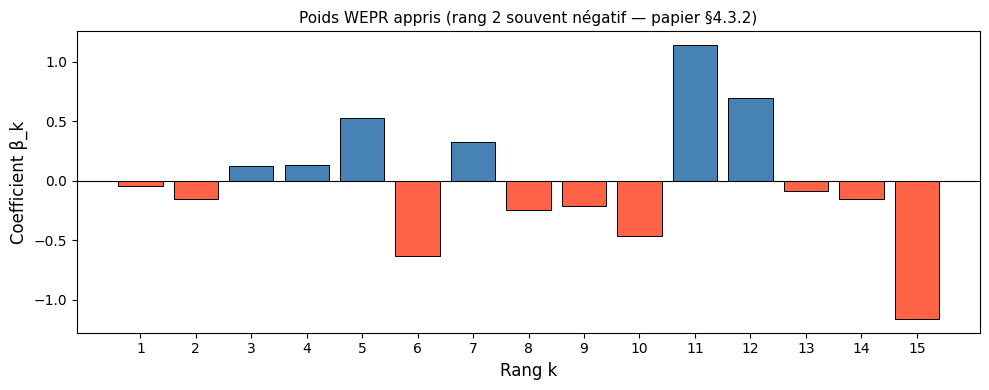

In [23]:

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["tomato" if c < 0 else "steelblue" for c in clf_wepr.coef_[0]]
bars = ax.bar(range(1, K_LOGPROBS + 1), clf_wepr.coef_[0], color=colors, edgecolor="black", linewidth=0.7)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Rang k", fontsize=12)
ax.set_ylabel("Coefficient β_k", fontsize=12)
ax.set_title(f"Poids WEPR appris "
             f"(rang 2 souvent négatif — papier §4.3.2)", fontsize=11)
ax.set_xticks(range(1, K_LOGPROBS + 1))
plt.tight_layout()
plt.savefig("wepr_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. WEPR — Évaluation & Courbe ROC

Reproduction de la **Figure 4** du papier :
- Courbe ROC de l'EPR  (score = −EPR)
- Courbe ROC du WEPR supervisé (score = σ(WEPR))

In [25]:
def compute_roc(
    y_true: np.ndarray,
    scores: np.ndarray,
) -> dict:
    """
    Calcule la courbe ROC et l'AUC.
    Entraînement et évaluation sur le même dataset.
    """
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc_val     = roc_auc_score(y_true, scores)
    return {"fpr": fpr, "tpr": tpr, "auc": auc_val}


def evaluate_epr_vs_wepr(
    df_eval: pd.DataFrame,
    X_eval: np.ndarray,
    y_eval: np.ndarray,
    scaler, clf,
    dataset_name: str,
) -> dict:
    """
    Évalue EPR baseline et WEPR sur un jeu de données.

    Score EPR  = -EPR  (EPR faible → confiant → score positif élevé)
    Score WEPR = σ(WEPR_K) = P(correct | features)  ∈ [0,1]
    """
    # Scores EPR : -EPR (bas EPR = haute confiance)
    scores_epr  = -df_eval["epr"].values

    # Scores WEPR : P(correct)
    scores_wepr = wepr_score(scaler, clf, X_eval)

    roc_epr  = compute_roc(y_eval, scores_epr)
    roc_wepr = compute_roc(y_eval, scores_wepr)

    pr_auc_epr  = average_precision_score(y_eval, scores_epr)
    pr_auc_wepr = average_precision_score(y_eval, scores_wepr)

    print(f"\n{'='*60}")
    print(f"  Dataset        : {dataset_name}")
    print(f"  EPR  — ROC-AUC : {roc_epr['auc']:.4f}   PR-AUC={pr_auc_epr:.4f}")
    print(f"  WEPR — ROC-AUC : {roc_wepr['auc']:.4f}   PR-AUC={pr_auc_wepr:.4f}")
    print(f"{'='*60}")

    return {
        "dataset"      : dataset_name,
        "roc_epr"      : roc_epr,
        "roc_wepr"     : roc_wepr,
        "pr_auc_epr"   : pr_auc_epr,
        "pr_auc_wepr"  : pr_auc_wepr,
        "scores_epr"   : scores_epr,
        "scores_wepr"  : scores_wepr,
        "y_true"       : y_eval,
    }


In [26]:

eval_wq = evaluate_epr_vs_wepr(
    df_eval      = df_wq,
    X_eval       = X_wq,
    y_eval       = y_wq,
    scaler       = scaler_wepr,
    clf          = clf_wepr,
    dataset_name = "WebQuestions",
)




  Dataset        : WebQuestions
  EPR  — ROC-AUC : 0.5523   PR-AUC=0.1329
  WEPR — ROC-AUC : 0.6313   PR-AUC=0.1655



## PLot

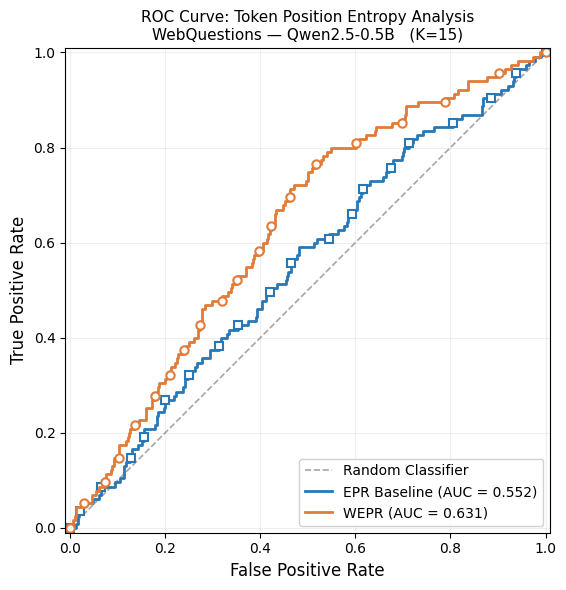

Figure sauvegardée : roc_epr_vs_wepr.png


In [28]:
def plot_roc_epr_vs_wepr(
    eval_results: dict,
    ax,
):
    """
    Trace les courbes ROC EPR vs WEPR — reproduction fidèle de la Figure 4 du papier.
    Style : fond blanc, axes larges, marqueurs carrés (EPR) et ronds (WEPR).
    """
    roc_epr  = eval_results["roc_epr"]
    roc_wepr = eval_results["roc_wepr"]
    dataset  = eval_results["dataset"]

    # Diagonale aléatoire
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1.2,
            label="Random Classifier", alpha=0.7)

    n_markers = 20
    idx_epr   = np.linspace(0, len(roc_epr["fpr"]) - 1, n_markers, dtype=int)

    ax.plot(roc_epr["fpr"], roc_epr["tpr"],
            color="#2878b5", linewidth=2.0,
            label=f'EPR Baseline (AUC = {roc_epr["auc"]:.3f})')
    ax.plot(roc_epr["fpr"][idx_epr], roc_epr["tpr"][idx_epr],
            "s", color="#2878b5", markersize=6, markerfacecolor="white",
            markeredgewidth=1.5)

    idx_wepr = np.linspace(0, len(roc_wepr["fpr"]) - 1, n_markers, dtype=int)

    ax.plot(roc_wepr["fpr"], roc_wepr["tpr"],
            color="#e07b39", linewidth=2.0,
            label=f'WEPR (AUC = {roc_wepr["auc"]:.3f})')
    ax.plot(roc_wepr["fpr"][idx_wepr], roc_wepr["tpr"][idx_wepr],
            "o", color="#e07b39", markersize=6, markerfacecolor="white",
            markeredgewidth=1.5)

    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.set_xlabel("False Positive Rate", fontsize=12)
    ax.set_ylabel("True Positive Rate",  fontsize=12)
    ax.set_title(
        f"ROC Curve: Token Position Entropy Analysis\n"
        f"{dataset} — {ACTIVE_MODEL_KEY}   (K={K_LOGPROBS})",
        fontsize=11,
    )
    ax.legend(loc="lower right", fontsize=10, framealpha=0.9)
    ax.set_aspect("equal")
    ax.grid(True, alpha=0.2)

fig, ax = plt.subplots(figsize=(7, 6))

ax.set_title(
    f"EPR vs WEPR "
    f"Modèle : {ACTIVE_MODEL_KEY}   K={K_LOGPROBS}   T={T_SAMPLE}",
    fontsize=13,
    fontweight="bold",
)

plot_roc_epr_vs_wepr(eval_wq, ax)

plt.tight_layout()
plt.savefig("roc_epr_vs_wepr.png", dpi=200, bbox_inches="tight")
plt.show()

print("Figure sauvegardée : roc_epr_vs_wepr.png")